# Simple-Span Plate Girder: Loads → Influence Lines → Distribution → Checks → Rating

An end-to-end walkthrough of the `civilpy.structural.aashto.lrfd` toolkit on an
invented bridge so every number can be traced by hand:

**Example bridge** — a single 84-ft simple span carrying a two-lane county road:

* 5 welded plate girders spaced at 8.25 ft, 50-ksi steel
* 8.5-in composite deck (f'c = 4.5 ksi), 2.5-in haunch
* Girder: 16 x 1.0 top flange, 60 x 0.5625 web, 18 x 1.25 bottom flange
* Cross-frames at 21 ft (quarter points)

The workflow: dead-load analysis → HL-93 live load from the influence line →
live-load distribution factors → capacity checks → an LRFR inventory rating.

In [1]:
import matplotlib.pyplot as plt
from civilpy.structural.beam_bending import Beam, DistributedLoadV
from civilpy.structural.influence_lines import InfluenceLine
from civilpy.structural.aashto import lrfd

SPAN = 84.0          # ft
S = 8.25             # girder spacing, ft
FY = 50.0            # ksi

## 1. Dead load on the composite girder

Steel + deck + haunch tributary to an interior girder, plus a wearing-surface
allowance.  The `Beam` object gives the familiar shear/moment diagrams.

In [2]:
# component dead loads (kip/ft on one interior girder)
w_steel = 0.270                      # girder + cross frames, estimated
w_deck = 8.5 / 12 * 0.150 * S        # slab tributary width
w_haunch_forms = 0.075
w_dc = w_steel + w_deck + w_haunch_forms
w_dw = 0.025 * S                     # 25 psf future wearing surface

beam = Beam(SPAN)
beam.pinned_support = 0
beam.rolling_support = SPAN
beam.add_loads([DistributedLoadV(f"{w_dc + w_dw}", (0, SPAN))])
beam.get_reaction_forces()

m_dc = w_dc * SPAN**2 / 8.0          # kip-ft at midspan
m_dw = w_dw * SPAN**2 / 8.0
print(f"w_DC = {w_dc:.3f} klf -> M_DC = {m_dc:.0f} kip-ft")
print(f"w_DW = {w_dw:.3f} klf -> M_DW = {m_dw:.0f} kip-ft")

w_DC = 1.222 klf -> M_DC = 1077 kip-ft
w_DW = 0.206 klf -> M_DW = 182 kip-ft


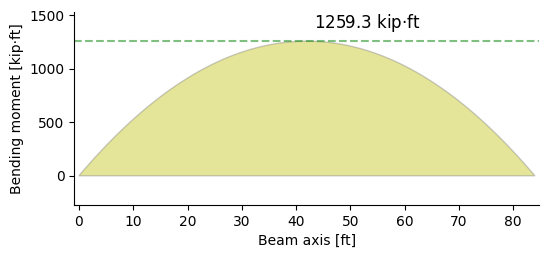

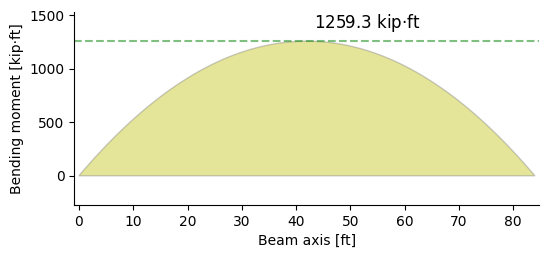

In [3]:
beam.plot_bending_moment()
plt.gcf()

## 2. HL-93 live load from the influence line

The midspan moment influence line, with the design truck stepped across it and
lane load on the positive region (3.6.1.3).

truck: 1232 kip-ft  (tandem governs: False)
lane:  564 kip-ft
HL-93 total (with IM on the truck): 2203 kip-ft per lane


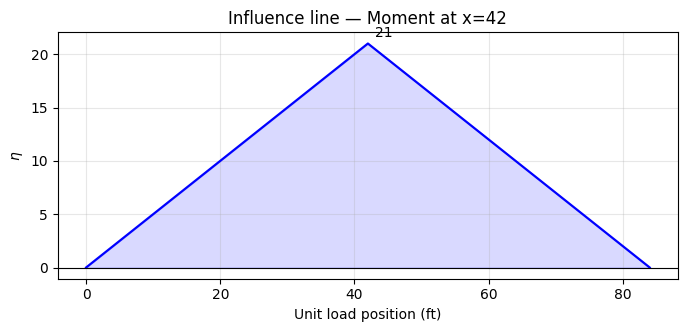

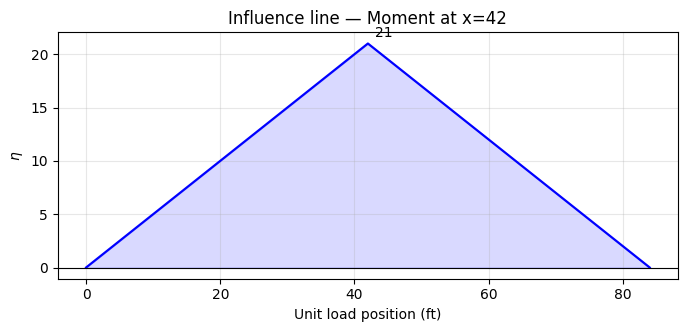

In [4]:
il = InfluenceLine.moment(span=SPAN, section=SPAN / 2)
hl93 = il.hl93_effect()                 # kip-ft per lane, IM included
print(f"truck: {hl93['truck']:.0f} kip-ft  (tandem governs: {hl93['tandem_governs']})")
print(f"lane:  {hl93['lane']:.0f} kip-ft")
print(f"HL-93 total (with IM on the truck): {hl93['total']:.0f} kip-ft per lane")
il.plot()

## 3. Live-load distribution (4.6.2.2)

Composite section stiffness feeds the longitudinal stiffness parameter Kg, and
the interior-girder moment DF converts lanes to a per-girder moment.

In [5]:
k_g = lrfd.longitudinal_stiffness_kg(
    n_modular=8.0, i_girder=58_000.0, a_girder=63.0, e_g=42.0)
df = lrfd.moment_df_interior(s_ft=S, l_ft=SPAN, t_s=8.5, k_g=k_g, n_beams=5)
print(f"Kg = {k_g:,.0f} in^4")
print(f"DF one lane  = {df.one_lane:.3f}")
print(f"DF multilane = {df.multi_lane:.3f}  -> governing {df.governing:.3f}")
print(f"within the table's applicability range: {df.applicable}")

m_ll = hl93["total"] * df.governing
print(f"\nM_LL+IM per girder = {m_ll:.0f} kip-ft")

Kg = 1,353,056 in^4
DF one lane  = 0.496
DF multilane = 0.700  -> governing 0.700
within the table's applicability range: True

M_LL+IM per girder = 1541 kip-ft


## 4. Capacity checks

The compact composite section reaches Mp with a small ductility penalty
(6.10.7.1.2); the chart shows how the *noncomposite* flange capacity would have
decayed with unbraced length (6.10.8.2.3) — useful for the construction
condition before the deck cures.

In [6]:
# plastic-moment analysis of the composite section (D6.1 hand calc):
# steel T = 72.25 in^2 * 50 ksi acting ~40 in below the slab centroid
M_P = 142_800.0          # kip-in
check = lrfd.compact_composite_positive_flexure(
    m_p=M_P, d_p=9.5, d_t=72.25)
print(f"Mn = {check.capacity / 12:.0f} kip-ft "
      f"(Dp/Dt = {9.5 / 72.25:.3f}, phi_f = {check.phi})")

Mn = 11638 kip-ft (Dp/Dt = 0.131, phi_f = 1.0)


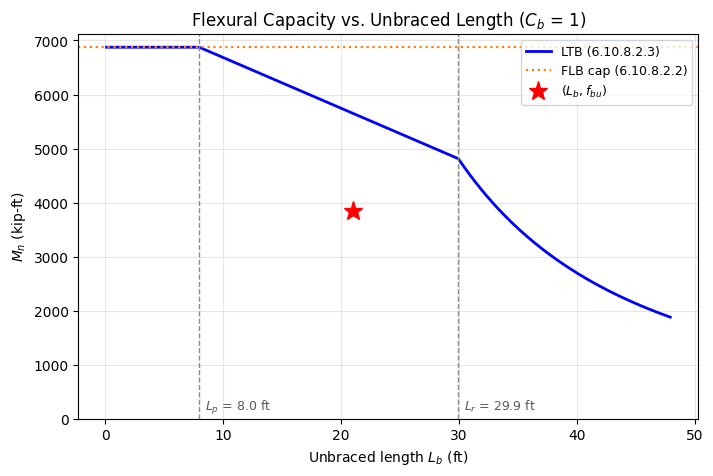

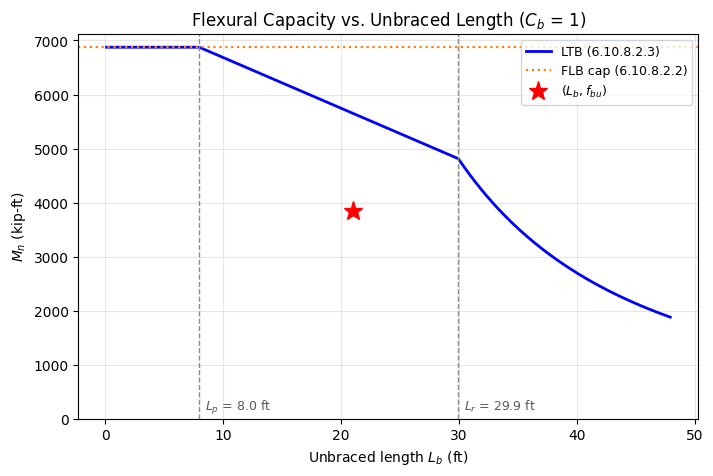

In [7]:
from civilpy.structural.aashto.lrfd.plots import plot_mn_vs_lb
plot_mn_vs_lb(b_fc=16.0, t_fc=1.0, d_c=30.0, t_w=0.5625,
              f_yc=FY, f_yw=FY, s_xc=1_650.0, l_b=21.0 * 12.0,
              f_bu=28.0)

## 5. LRFR inventory and operating rating (MBE 6A.4.2.1)

The rating composes the factored capacity with the dead- and live-load
effects.  Moments are per girder, kip-ft throughout.

In [8]:
capacity_kipft = check.factored_capacity / 12.0
rf_inv = lrfd.rating_factor(
    nominal_capacity=check.capacity / 12.0, phi=check.phi,
    dc=m_dc, dw=m_dw, ll_im=m_ll, level="inventory")
rf_opr = lrfd.rating_factor(
    nominal_capacity=check.capacity / 12.0, phi=check.phi,
    dc=m_dc, dw=m_dw, ll_im=m_ll, level="operating")
print(f"RF inventory = {rf_inv.capacity:.2f}")
print(f"RF operating = {rf_opr.capacity:.2f}")

RF inventory = 3.71
RF operating = 4.81


A rating factor well above 1.0 at inventory means the girder carries the full
HL-93 with the long-term margins intact — this section was sized generously
(a future deck widening was assumed), and the rating quantifies that reserve.
From here, `lrfd.legal_load_factor` / `lrfd.permit_load_factor` slot straight
into the same equation for legal and permit vehicles.